In [ ]:
#!pip install xgboost # used in Google colab, on cluster make sure xgboost is installed in the environment

In [ ]:
#from google.colab import drive # only needed on Colab
#drive.mount('/content/drive') # only needed on Colab
file_prefix = '/home/javier.roulet/cogwheel-machine/data/run_7/training_data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Get the input and output data
simulation_data = np.load(file_prefix+'/compressed_data.npy')
folded_sampled_params = np.load(file_prefix+'/folded_sampled_params.npy')
input_data = np.hstack((folded_sampled_params,simulation_data))

unfolding_labels = np.load(file_prefix+'/unfolding_labels.npy')
output_data = unfolding_labels
print(np.shape(input_data))
# Prepare data
X_train, X_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.1, random_state=42)
print(np.shape(X_test))
print(np.shape(y_test))
xg_train = xgb.DMatrix(X_train, label=y_train)
xg_test = xgb.DMatrix(X_test, label=y_test)

(5000000, 60)
(500000, 60)
(500000,)


In [ ]:
# setup parameters for xgboost
param = {}
# use softmax multi-class classification
param['objective'] = 'multi:softprob'
# scale weight of positive examples
param['eta'] = 0.1
param['max_depth'] = 6
#param['nthread'] = 4 # No values for all available cores
param['num_class'] = 16 # Number of classification classes
param['verbosity'] = 0 #2 for information as it trains
param['device'] = 'cuda'

#watchlist = [(xg_train, 'train'), (xg_test, 'test')]
num_round = 5000
bst = xgb.train(param, xg_train, num_round, evals=[(xg_train, 'train'), (xg_test, 'test')],early_stopping_rounds=10) #, watchlist)

[0]	train-mlogloss:2.75255	test-mlogloss:2.75267
[1]	train-mlogloss:2.73477	test-mlogloss:2.73500
[2]	train-mlogloss:2.71928	test-mlogloss:2.71964
[3]	train-mlogloss:2.70512	test-mlogloss:2.70560
[4]	train-mlogloss:2.69281	test-mlogloss:2.69341
[5]	train-mlogloss:2.68169	test-mlogloss:2.68239
[6]	train-mlogloss:2.67157	test-mlogloss:2.67239
[7]	train-mlogloss:2.66245	test-mlogloss:2.66338
[8]	train-mlogloss:2.65337	test-mlogloss:2.65442
[9]	train-mlogloss:2.64531	test-mlogloss:2.64646
[10]	train-mlogloss:2.63852	test-mlogloss:2.63980
[11]	train-mlogloss:2.63179	test-mlogloss:2.63317
[12]	train-mlogloss:2.62553	test-mlogloss:2.62700
[13]	train-mlogloss:2.61885	test-mlogloss:2.62041
[14]	train-mlogloss:2.61322	test-mlogloss:2.61486
[15]	train-mlogloss:2.60673	test-mlogloss:2.60846
[16]	train-mlogloss:2.60051	test-mlogloss:2.60235
[17]	train-mlogloss:2.59426	test-mlogloss:2.59623
[18]	train-mlogloss:2.58835	test-mlogloss:2.59043
[19]	train-mlogloss:2.58192	test-mlogloss:2.58410
[20]	train

500 training epochs

In [ ]:
# get prediction
pred_prob = bst.predict(xg_test).reshape(y_test.shape[0], 16)
print(pred_prob)
pred_label = np.argmax(pred_prob, axis=1)
print(pred_label)
error_rate = np.sum(pred_label != y_test) / y_test.shape[0]
print(error_rate)
print('Test error using softprob = {}'.format(error_rate))

[[0.1154238  0.0015045  0.00197238 ... 0.00106678 0.00166303 0.13497612]
 [0.04244496 0.09983286 0.02670849 ... 0.11708704 0.02681893 0.07827228]
 [0.10693578 0.01103341 0.00957409 ... 0.01342359 0.01112278 0.11787693]
 ...
 [0.09429245 0.00223702 0.00132074 ... 0.00285591 0.0016488  0.12185875]
 [0.00775074 0.05372449 0.19413711 ... 0.04872012 0.2033067  0.00328409]
 [0.03079941 0.09498388 0.04164218 ... 0.12657277 0.03289327 0.07858289]]
[11 13  4 ...  7 14 13]
0.86523
Test error using softprob = 0.86523


In [ ]:
simulation_data_test = np.load(file_prefix+'/compressed_data_test.npy')
folded_sampled_params_test = np.load(file_prefix+'/folded_sampled_params_test.npy')
input_data_test = np.hstack((folded_sampled_params_test,simulation_data_test))

unfolding_labels_test = np.load(file_prefix+'/unfolding_labels_test.npy')
output_data_test = unfolding_labels_test
xg_data_test = xgb.DMatrix(input_data_test, label=output_data_test)

In [ ]:
pred_prob_test = bst.predict(xg_data_test).reshape(output_data_test.shape[0], 16)
print(pred_prob_test)
print(np.shape(pred_prob_test))
print(np.shape(unfolding_labels_test))
print(unfolding_labels_test[0])
print(pred_prob_test[0])
print(unfolding_labels_test[1])
print(pred_prob_test[1])
print(unfolding_labels_test[2])
print(pred_prob_test[2])

[[0.0390416  0.00652702 0.20000178 ... 0.00843238 0.16049847 0.00619437]
 [0.0334218  0.11770201 0.04203786 ... 0.08993461 0.03603544 0.07939754]
 [0.00898741 0.0012481  0.00046343 ... 0.00046348 0.00031515 0.23443055]
 ...
 [0.04514583 0.09208469 0.08672259 ... 0.08350881 0.08199234 0.03170962]
 [0.12055036 0.00236136 0.00338537 ... 0.00325959 0.00238034 0.11814424]
 [0.03208074 0.00328576 0.00058745 ... 0.00344456 0.00076644 0.21487719]]
(10000, 16)
(10000,)
10
[0.0390416  0.00652702 0.20000178 0.00315682 0.04271797 0.01110636
 0.2075503  0.00593116 0.05996034 0.00587591 0.17749044 0.00426302
 0.06125206 0.00843238 0.16049847 0.00619437]
0
[0.0334218  0.11770201 0.04203786 0.09237197 0.03688355 0.09231848
 0.03329736 0.06417251 0.04525181 0.09839223 0.02846082 0.07109503
 0.03922697 0.08993461 0.03603544 0.07939754]
11
[8.9874053e-03 1.2481028e-03 4.6343234e-04 2.6896513e-01 7.1293321e-03
 6.7270297e-04 2.6110208e-04 2.2581632e-01 1.4542612e-02 7.3252368e-04
 2.8031896e-04 2.2209854e

Probabilistic Confusion Matrix:
[[0.10820028 0.03241215 0.04227781 0.06679324 0.10810632 0.03271327
  0.04160545 0.06800289 0.10890958 0.03254224 0.04199274 0.06654263
  0.1080633  0.03222162 0.04258056 0.06703591]
 [0.03324915 0.10508261 0.07177152 0.03923449 0.03304657 0.1055503
  0.07136075 0.03989808 0.03292714 0.10661879 0.0710294  0.03957283
  0.03345834 0.10585926 0.07144472 0.03989606]
 [0.03986479 0.07118372 0.10713403 0.03296031 0.04008553 0.06968866
  0.10586236 0.03420876 0.03929627 0.06986946 0.10697773 0.03359684
  0.03976192 0.06942125 0.10670291 0.03338547]
 [0.06765907 0.04046248 0.03436324 0.10811176 0.06871074 0.04048105
  0.03372709 0.10507133 0.06751097 0.04145639 0.03414102 0.10833329
  0.06826467 0.0406497  0.03444104 0.10661615]
 [0.1080111  0.03401398 0.04020495 0.06847628 0.10689897 0.03360939
  0.04122427 0.06935738 0.10764818 0.03344394 0.03957996 0.06765523
  0.10813104 0.03349309 0.04001053 0.06824171]
 [0.03565792 0.10177776 0.06899039 0.04140484 0.036360

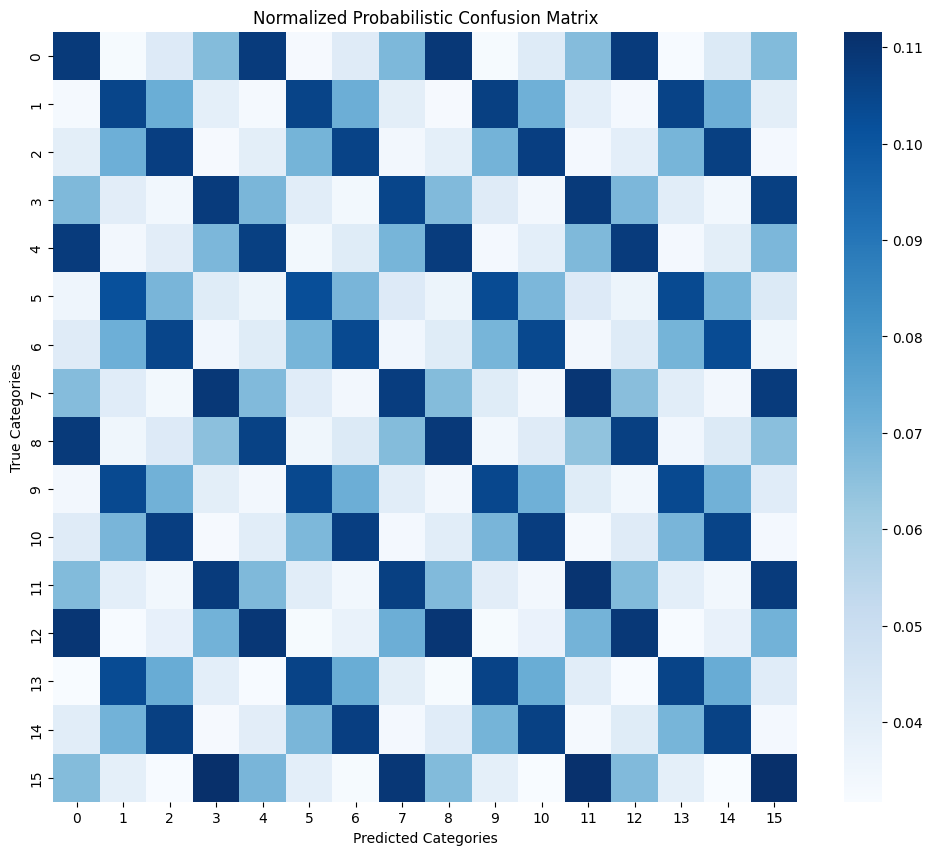

In [ ]:
# Initialize a confusion matrix of size (16, 16)
probabilistic_conf_matrix = np.zeros((16, 16))

#for i in range()

# Populate the probabilistic confusion matrix
for true_label, probabilities in zip(unfolding_labels_test, pred_prob_test):
    probabilistic_conf_matrix[true_label] += probabilities

# Normalize rows for better interpretation (optional)
row_sums = probabilistic_conf_matrix.sum(axis=1, keepdims=True)
normalized_conf_matrix = probabilistic_conf_matrix / (row_sums + 1e-9)  # Avoid division by zero

# Print the probabilistic confusion matrix
print("Probabilistic Confusion Matrix:")
print(normalized_conf_matrix)

# Optional: Visualize the normalized confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(normalized_conf_matrix, annot=False, cmap="Blues", xticklabels=range(16), yticklabels=range(16))
plt.xlabel("Predicted Categories")
plt.ylabel("True Categories")
plt.title("Normalized Probabilistic Confusion Matrix")
plt.show()

2529 training epochs

Probabilistic Confusion Matrix:
[[0.11539522 0.03055193 0.03991489 0.06381701 0.11391837 0.03053452
  0.04068403 0.06287204 0.11646584 0.02963201 0.04132102 0.06352746
  0.11697055 0.02951465 0.04100598 0.06387449]
 [0.03104885 0.11480517 0.06678518 0.0378285  0.0306057  0.11495944
  0.06731432 0.03785028 0.03008908 0.11395917 0.06717791 0.03844656
  0.03022049 0.11378054 0.0679388  0.03718999]
 [0.03831716 0.06568883 0.11589971 0.03051369 0.03817402 0.06549595
  0.11652636 0.03093059 0.03783004 0.06473245 0.11654583 0.03052686
  0.03831221 0.06425026 0.11641528 0.02984075]
 [0.06431761 0.03994245 0.03058223 0.11395833 0.06458269 0.03941273
  0.0311578  0.11561436 0.063884   0.03951721 0.03174856 0.11579971
  0.06323871 0.0399552  0.03171254 0.11457588]
 [0.11402131 0.03078852 0.03940667 0.06480216 0.11499833 0.03115053
  0.0396341  0.06392189 0.11788312 0.03083276 0.03919649 0.06364827
  0.11525149 0.03087788 0.03880135 0.06478513]
 [0.03361654 0.11076038 0.06428116 0.04079294 0.03345

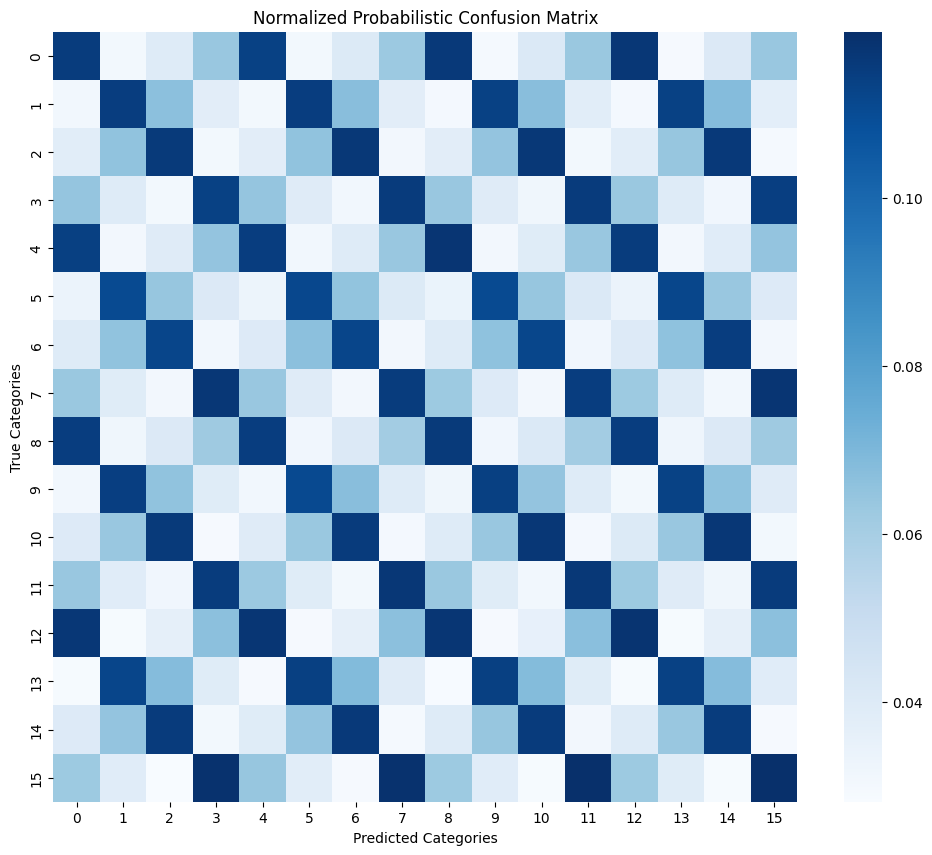

In [ ]:
pred_prob_test = bst.predict(xg_data_test).reshape(output_data_test.shape[0], 16)
# Initialize a confusion matrix of size (16, 16)
probabilistic_conf_matrix = np.zeros((16, 16))

#for i in range()

# Populate the probabilistic confusion matrix
for true_label, probabilities in zip(unfolding_labels_test, pred_prob_test):
    probabilistic_conf_matrix[true_label] += probabilities

# Normalize rows for better interpretation (optional)
row_sums = probabilistic_conf_matrix.sum(axis=1, keepdims=True)
normalized_conf_matrix = probabilistic_conf_matrix / (row_sums + 1e-9)  # Avoid division by zero

# Print the probabilistic confusion matrix
print("Probabilistic Confusion Matrix:")
print(normalized_conf_matrix)

# Optional: Visualize the normalized confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(normalized_conf_matrix, annot=False, cmap="Blues", xticklabels=range(16), yticklabels=range(16))
plt.xlabel("Predicted Categories")
plt.ylabel("True Categories")
plt.title("Normalized Probabilistic Confusion Matrix")
plt.show()

In [ ]:
# Define KL Divergence loss function
def kl_divergence(y_true, y_pred):
    y_pred = y_pred.get_data().toarray()
    y_pred_prob = 1 / (1 + np.exp(- y_pred))  # Sigmoid for binary classification
    grad = y_pred_prob - y_true
    hess = y_pred_prob * (1 - y_pred_prob)
    return grad, hess